<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C9_Arbol_Decisi%C3%B3n_(Libro).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

¿Por qué usar Árboles de Decisión?

Los árboles de decisión ofrecen varias ventajas, entre ellas:

    Fácil interpretación: Son representables visualmente, lo que facilita su comprensión.
    Capacidad de manejar datos categóricos y numéricos.
    No requieren normalización de datos.
    Pueden manejar valores faltantes en algunos algoritmos como C4.5.

Aplicaciones de los Árboles de Decisión

    Medicina: Diagnóstico de enfermedades basado en síntomas.
    Finanzas: Predicción de clientes con alto riesgo de impago en préstamos.
    Marketing: Segmentación de clientes según su comportamiento de compra.
    Derecho: Clasificación de casos jurídicos en categorías específicas.
    Industria: Predicción de fallas en maquinarias con base en mediciones sensoriales.


Ejemplo Real

Un banco quiere determinar si un cliente debe recibir un préstamo. Se pueden usar criterios como:

    Ingreso anual (¿superior a $50,000?)
    Historial de pagos (¿ha tenido deudas impagas?)
    Edad del cliente (¿es menor de 30 años?)

El modelo toma decisiones basadas en estos atributos y asigna una clasificación: "Aprobado" o "Rechazado".

Estructura de un Árbol de Decisión

Un árbol de decisión está compuesto por:

    Nodo Raíz: Representa el atributo principal sobre el cual se toma la primera decisión.
    Nodos Intermedios (de decisión): Representan criterios de partición sobre diferentes atributos.
    Ramas: Son las conexiones entre los nodos, representando una respuesta a la condición planteada en el nodo.
    Nodos Hoja: Representan la predicción final o resultado del modelo.

Ejemplo: Un Árbol de Decisión para Aprobar un Préstamo

¿Ingreso > 50,000?
       /               Sí          No
      /              ¿Historial bueno?   Rechazado
    /         Sí         No
Aprobado   Rechazado

    Si los ingresos son mayores a $50,000, se considera el historial crediticio.
    Si el historial es bueno, el préstamo es aprobado.
    Si cualquiera de estos factores es negativo, el préstamo es rechazado.


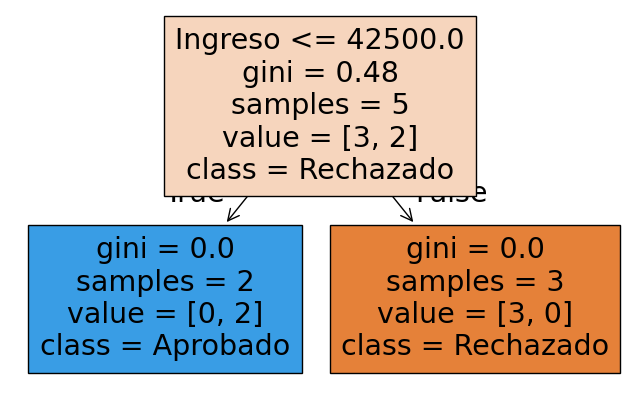

Conclusión:
    El árbol de decisión divide los datos en ramas según condiciones lógicas.
    La representación gráfica ayuda a comprender fácilmente el proceso de toma de decisiones.


In [ ]:
#Ejemplo de Código en Python – Visualización de un Árbol de Decisión
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Datos ficticios de ingresos y historial crediticio
X = [[60000, 1], [35000, 0], [80000, 1], [20000, 0], [50000, 1]]
y = ["Aprobado", "Rechazado", "Aprobado", "Rechazado", "Aprobado"]

# Crear y entrenar el árbol
tree = DecisionTreeClassifier(criterion="gini", max_depth=3)
tree.fit(X, y)

# Graficar el árbol
plt.figure(figsize=(8, 5))
plot_tree(tree, feature_names=["Ingreso", "Historial"],
          class_names=["Rechazado", "Aprobado"], filled=True)
plt.show()
print("Conclusión:")
print("    El árbol de decisión divide los datos en ramas según condiciones lógicas.")
print("    La representación gráfica ayuda a comprender fácilmente el proceso de toma de decisiones.")


1.1. Tipos de Árboles de Decisión

    Árboles de Clasificación: Se utilizan cuando la variable objetivo es categórica (Ejemplo: "Sí" o "No").
    Utilizan métricas como Índice Gini o Entropía para determinar las divisiones óptimas. Ejemplo: Diagnosticar
    si un paciente tiene una enfermedad (Sí/No).

    Árboles de Regresión: Se utilizan cuando la variable objetivo es numérica continua. Utilizan métricas
    como Error Cuadrático Medio (MSE) para minimizar errores en predicciones. Ejemplo: Predecir el precio de
    una casa en función de su tamaño y ubicación.

Comparación entre Clasificación y Regresión

| Tipo de Árbol | Variable Objetivo | Ejemplo |
| :------------ | :---------------- | :------ |
| Clasificación | Categórica (Sí/No) | Diagnóstico de una enfermedad |
| Regresión     | Continua (Números) | Predicción del precio de una casa |

In [ ]:
#Ejemplo de Código en Python – Comparación de Clasificación vs. Regresión
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Datos simulados
X_class = np.array([[1], [2], [3], [4], [5]])
y_class = np.array(["Bajo", "Bajo", "Medio", "Alto", "Alto"])

X_reg = np.array([[1], [2], [3], [4], [5]])
y_reg = np.array([10000, 15000, 25000, 50000, 70000])

# Modelos
clf = DecisionTreeClassifier(max_depth=2).fit(X_class, y_class)
reg = DecisionTreeRegressor(max_depth=2).fit(X_reg, y_reg)

# Predicción de nuevos valores
print("Clasificación:", clf.predict([[3.5]]))  # Esperado: "Medio" o "Alto"
print("Regresión:", reg.predict([[3.5]]))       # Esperado: Un valor numérico intermedio

print("Conclusión:")
print("    Los árboles de clasificación predicen categorías discretas (Ejemplo: Bajo, Medio, Alto).")
print("    Los árboles de regresión predicen valores continuos (Ejemplo: un precio en dólares).")


Clasificación: ['Medio']
Regresión: [25000.]
Conclusión:
    Los árboles de clasificación predicen categorías discretas (Ejemplo: Bajo, Medio, Alto).
    Los árboles de regresión predicen valores continuos (Ejemplo: un precio en dólares).


# Sección 2: Construcción y Algoritmos
**2.1. ¿Cómo se construye un Árbol de Decisión?**

Un árbol de decisión se construye dividiendo repetidamente los datos en subconjuntos con base en preguntas sobre sus atributos.

**Ejemplo**: Si queremos clasificar a personas según si compran un automóvil, podríamos hacer preguntas como:

    ¿Tiene ingresos superiores a $30,000?
    ¿Vive en una ciudad o en zona rural?
    ¿Es mayor de 25 años?

Cada pregunta divide los datos en dos subconjuntos, y este proceso continúa hasta que se llega a un nodo hoja.



**Criterios para dividir los datos**

Para decidir qué atributo usar en cada nodo, los algoritmos de árboles de decisión utilizan diferentes métricas:

| Métrica | Uso | Descripción |
| :------ | :-- | :---------- |
| Entropía | ID3 y C4.5 | Mide la incertidumbre en los datos antes y después de una división. |
| Ganancia de Información | ID3 y C4.5 | Calcula cuánto reduce la entropía una partición. |
| Índice Gini | CART | Mide la pureza de los nodos después de una partición. |
| Error Cuadrático Medio (MSE) | Árboles de Regresión | Minimiza la diferencia entre los valores reales y predichos. |

**Ejemplo: Cálculo de Entropía y Gini**

Si tenemos 10 ejemplos y 7 pertenecen a la clase "Sí" y 3 a la clase "No", podemos calcular:

    Entropía: H = -0.7*log2(0.7) - 0.3*log2(0.3) ≈ 0.88
    — Una entropía de 0.88 indica que el conjunto es relativamente mixto (incierto).
    Índice Gini: Gini = 1 - (0.7² + 0.3²) = 1 - (0.49 + 0.09) ≈ 0.42
    — Un índice Gini de 0.42 indica que el conjunto tiene diversidad de clases.

En general, cuanto más baja es la Entropía o el Gini, mejor es la partición.

**2.2. Algoritmos Populares para Construcción de Árboles**

  1. ID3 (Iterative Dichotomiser 3): Utiliza Ganancia de Información basada en Entropía para seleccionar los mejores atributos.
  Limitaciones: No maneja atributos numéricos ni valores faltantes.
  Ejemplo de Aplicación: Clasificación de correos en spam y no spam.
  2. C4.5: Es una mejora de ID3 que puede manejar atributos numéricos y datos faltantes.
  Utiliza Índice de Ganancia, que ajusta la ganancia de información para evitar sesgos hacia atributos con muchos valores.
  Ejemplo de Aplicación: Diagnóstico médico basado en síntomas.
  3. CART (Classification and Regression Trees): Utiliza Índice Gini en clasificación y MSE en regresión.
  Solo genera árboles binarios (cada nodo tiene exactamente dos ramas).
  Ejemplo de Aplicación: Predicción de precios de viviendas.

**Comparación de Algoritmos**

| Algoritmo | Criterio de División | Soporta Atributos Numéricos | Ramas Múltiples |
| :-------- | :------------------- | :-------------------------- | :-------------- |
| ID3       | Ganancia de Información (Entropía) | No                          | Sí              |
| C4.5      | Índice de Ganancia   | Sí                          | Sí              |
| CART      | Gini / MSE           | Sí                          | No (Binario)    |

**2.3. Implementación en Python: Comparación de Algoritmos**

In [ ]:
#Ejemplo: Comparar ID3 y CART en Clasificación
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Cargar dataset Titanic
df = sns.load_dataset("titanic").dropna()

# Preprocesamiento
df["sex"] = df["sex"].map({"male": 1, "female": 0})
X = df[["age", "fare", "sex", "class"]]
y = df["survived"]

# Convertir "class" en variable numérica
X = pd.get_dummies(X, drop_first=True)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Árbol ID3 (simulado con entropy en scikit-learn)
tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
tree_id3.fit(X_train, y_train)
y_pred_id3 = tree_id3.predict(X_test)

# Árbol CART (scikit-learn usa Gini por defecto)
tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree_cart.fit(X_train, y_train)
y_pred_cart = tree_cart.predict(X_test)

# Evaluación de precisión
print("Precisión ID3 (Entropía):", accuracy_score(y_test, y_pred_id3))
print("Precisión CART (Gini):", accuracy_score(y_test, y_pred_cart))

print("Conclusión:")
print("    ID3 usa Entropía y suele generar árboles más grandes y detallados.")
print("    CART usa Gini y tiende a ser más eficiente en árboles binarios.")


Precisión ID3 (Entropía): 0.7027027027027027
Precisión CART (Gini): 0.7027027027027027
Conclusión:
    ID3 usa Entropía y suele generar árboles más grandes y detallados.
    CART usa Gini y tiende a ser más eficiente en árboles binarios.


# **Sección 3: Evaluación y Optimización de Árboles de Decisión**

*Objetivo*: Aprender a evaluar la calidad de un árbol de decisión y explorar técnicas para optimizar su desempeño.

**3.1. ¿Cómo Evaluar un Árbol de Decisión?**

Para Árboles de Clasificación:

    Precisión (Accuracy): Proporción de predicciones correctas.
    Matriz de Confusión: Muestra los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
    Precision, Recall y F1-score: Métricas clave para evaluar la calidad de la clasificación.
    Curva ROC-AUC: Indica la capacidad del modelo para separar las clases.

Para Árboles de Regresión:

    Coeficiente de Determinación (R²): Indica qué porcentaje de la variabilidad en los datos es explicada por el modelo.
    Error Cuadrático Medio (MSE): Mide el promedio de los errores al cuadrado.
    Error Absoluto Medio (MAE): Mide el error medio en términos absolutos.


Precisión del Árbol de Decisión: 0.7027027027027027

Matriz de Confusión:
 [[11  2]
 [ 9 15]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.55      0.85      0.67        13
           1       0.88      0.62      0.73        24

    accuracy                           0.70        37
   macro avg       0.72      0.74      0.70        37
weighted avg       0.77      0.70      0.71        37



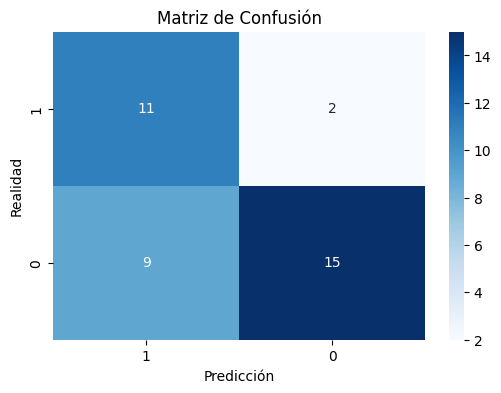

Conclusión:
    La matriz de confusión ayuda a visualizar los errores del modelo.
    Precisión y F1-score son útiles para evaluar el desempeño en clasificación.


In [ ]:
# Actividad: Evaluación de un Árbol de Clasificación en Python
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluación del modelo
y_pred = tree_cart.predict(X_test)
print("Precisión del Árbol de Decisión:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión")
plt.show()

print("Conclusión:")

print("    La matriz de confusión ayuda a visualizar los errores del modelo.")
print("    Precisión y F1-score son útiles para evaluar el desempeño en clasificación.")


**3.2. Problemas Comunes en Árboles de Decisión**

  1. Sobreajuste (Overfitting): Ocurre cuando el árbol es demasiado profundo y aprende patrones específicos del dataset de entrenamiento, reduciendo su capacidad de generalizar. Solución: Limitar la profundidad máxima (max_depth), el número mínimo de observaciones en un nodo (min_samples_split) y usar poda.
  2. Subajuste (Underfitting): Ocurre cuando el árbol es demasiado simple y no capta bien las relaciones en los datos. Solución: Aumentar la profundidad del árbol o incluir más variables predictoras.
  3. Selección de Atributos No Relevantes: Si el árbol usa atributos irrelevantes, puede generar predicciones inconsistentes. Solución: Aplicar selección de características para elegir solo las más importantes.
  4. Sensibilidad a los Datos Desequilibrados: Si hay clases desbalanceadas, el árbol puede favorecer la clase mayoritaria. Solución: Aplicar técnicas como balanceo de datos o ponderación de clases.


**3.3. Optimización de Árboles de Decisión**

**1. Ajuste de Parámetros (Hyperparameter Tuning)**

Se pueden optimizar los parámetros del árbol para evitar sobreajuste o subajuste:

| Parámetro | Descripción | Cómo Ajustarlo |
| :-------- | :---------- | :------------- |
| `max_depth` | Profundidad máxima del árbol | Reducir si hay sobreajuste |
| `min_samples_split` | Mínimo de muestras necesarias para dividir un nodo | Aumentar para evitar ramas pequeñas |
| `min_samples_leaf` | Mínimo de muestras en una hoja | Evita hojas con pocos datos |
| `max_features` | Número de atributos considerados en cada división | Reduce la complejidad del árbol |

In [ ]:
#Ejemplo: Ajuste Manual de Parámetros

tree_optimized = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                        min_samples_leaf=5, random_state=42)
tree_optimized.fit(X_train, y_train)
y_pred_opt = tree_optimized.predict(X_test)
print("Precisión optimizada:", accuracy_score(y_test, y_pred_opt))

Precisión optimizada: 0.8378378378378378


**2. Búsqueda de Parámetros con GridSearchCV**

Se puede automatizar la búsqueda de los mejores parámetros con GridSearchCV.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros
param_grid = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

# Aplicar GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


**3. Poda de Árboles**

  * Poda previa (Pre-pruning): Limita la profundidad del árbol durante su construcción (max_depth).
  * Poda posterior (Post-pruning): Permite que el árbol crezca completamente y luego elimina ramas innecesarias.


In [ ]:
# Actividad extensiva: Poda de un Árbol

from sklearn.tree import export_text

# Mostrar el árbol antes de poda
print(export_text(tree_cart, feature_names=X.columns.tolist()))

# Aplicar poda reduciendo max_depth
tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train, y_train)

# Mostrar el árbol después de la poda
print(export_text(tree_pruned, feature_names=X.columns.tolist()))

|--- sex <= 0.50
|   |--- age <= 3.00
|   |   |--- class: 0
|   |--- age >  3.00
|   |   |--- fare <= 11.49
|   |   |   |--- class: 1
|   |   |--- fare >  11.49
|   |   |   |--- class: 1
|--- sex >  0.50
|   |--- age <= 14.50
|   |   |--- class: 1
|   |--- age >  14.50
|   |   |--- fare <= 7.85
|   |   |   |--- class: 0
|   |   |--- fare >  7.85
|   |   |   |--- class: 0

|--- sex <= 0.50
|   |--- age <= 3.00
|   |   |--- class: 0
|   |--- age >  3.00
|   |   |--- fare <= 11.49
|   |   |   |--- class: 1
|   |   |--- fare >  11.49
|   |   |   |--- class: 1
|--- sex >  0.50
|   |--- age <= 14.50
|   |   |--- class: 1
|   |--- age >  14.50
|   |   |--- fare <= 7.85
|   |   |   |--- class: 0
|   |   |--- fare >  7.85
|   |   |   |--- class: 0



**Conclusión**:

  * Ajustar max_depth, min_samples_split y min_samples_leaf mejora la generalización del modelo.
  * GridSearchCV permite encontrar la mejor configuración automáticamente.
  * La poda de árboles evita que el modelo aprenda ruido en los datos.
